# Analyse SVM — Fiabilité Broyeur B430
Lecture du tableau bilan, visualisation 3D des paramètres (Durée, Température, Pression), et comparaison de modèles par Leave-One-Out Cross-Validation.

In [58]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'openpyxl', '-q'], check=True)

CompletedProcess(args=['c:\\Users\\mariu\\OneDrive\\Documents\\dèv\\projet_SVM_fiabila\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'openpyxl', '-q'], returncode=0)

In [59]:
# ── Mettre True pour re-lancer les optimisations (sections 8, 8b, 10) ────────
RUN_OPTIMIZATION = False

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, NuSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV

%matplotlib inline

## 1. Chargement et mise en forme des données
Le tableau original présente les BON PRODUITS à gauche et les MAUVAIS PRODUITS à droite. On reconstruit un DataFrame unique.

In [61]:
FILE_PATH = r'C:\Users\mariu\onedrive\documents\dèv\projet_SVM_fiabila\bilan SVM.xlsx'

raw = pd.read_excel(FILE_PATH, engine='openpyxl', header=None)

DATA_START = 4
DATA_END   = 24  # ligne MOY. exclue

def extract_group(col_duree, col_temp, col_pression, label_val):
    rows = []
    for i in range(DATA_START, DATA_END):
        lot   = raw.iat[i, col_duree - 1]
        duree = raw.iat[i, col_duree]
        temp  = raw.iat[i, col_temp]
        press = raw.iat[i, col_pression]
        if pd.isna(lot) or str(lot).strip() in ('', 'nan'):
            continue
        rows.append({'Lot': lot, 'Durée (min)': duree, 'Temp. (°C)': temp, 'Pression (bar)': press, 'label': label_val})
    return pd.DataFrame(rows)

bon     = extract_group(col_duree=2, col_temp=3, col_pression=4, label_val=1)
mauvais = extract_group(col_duree=7, col_temp=8, col_pression=9, label_val=0)

df = pd.concat([bon, mauvais], ignore_index=True)

# Convertir en float — 'N/D' devient NaN
for col in ['Durée (min)', 'Temp. (°C)', 'Pression (bar)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputer les N/D par la moyenne du groupe (BON ou MAUVAIS) pour garder les 28 lignes
df['Temp. (°C)'] = df.groupby('label')['Temp. (°C)'].transform(lambda g: g.fillna(g.mean()))

print(f'Total lignes : {len(df)}  (N/D imputés par moyenne de groupe)')
print(f"Bon : {(df['label']==1).sum()}  |  Mauvais : {(df['label']==0).sum()}")
df

Total lignes : 28  (N/D imputés par moyenne de groupe)
Bon : 20  |  Mauvais : 8


,Lot,Durée (min),Temp. (°C),Pression (bar),label
0,25020346,1019,46.680000,0.922,1
1,25050370,725,48.267368,0.818,1
2,25050371,668,42.000000,0.824,1
3,25050372,1114,47.820000,0.720,1
4,25060444,923,48.910000,1.140,1
5,25060445,775,43.200000,0.920,1
6,25060446,1472,49.690000,1.211,1
7,25060447,939,49.540000,1.109,1
8,25110700,755,49.490000,0.747,1
9,25110701,778,48.820000,0.714,1


## 2. Visualisation principale — Cube 3D + 3 projections orthogonales

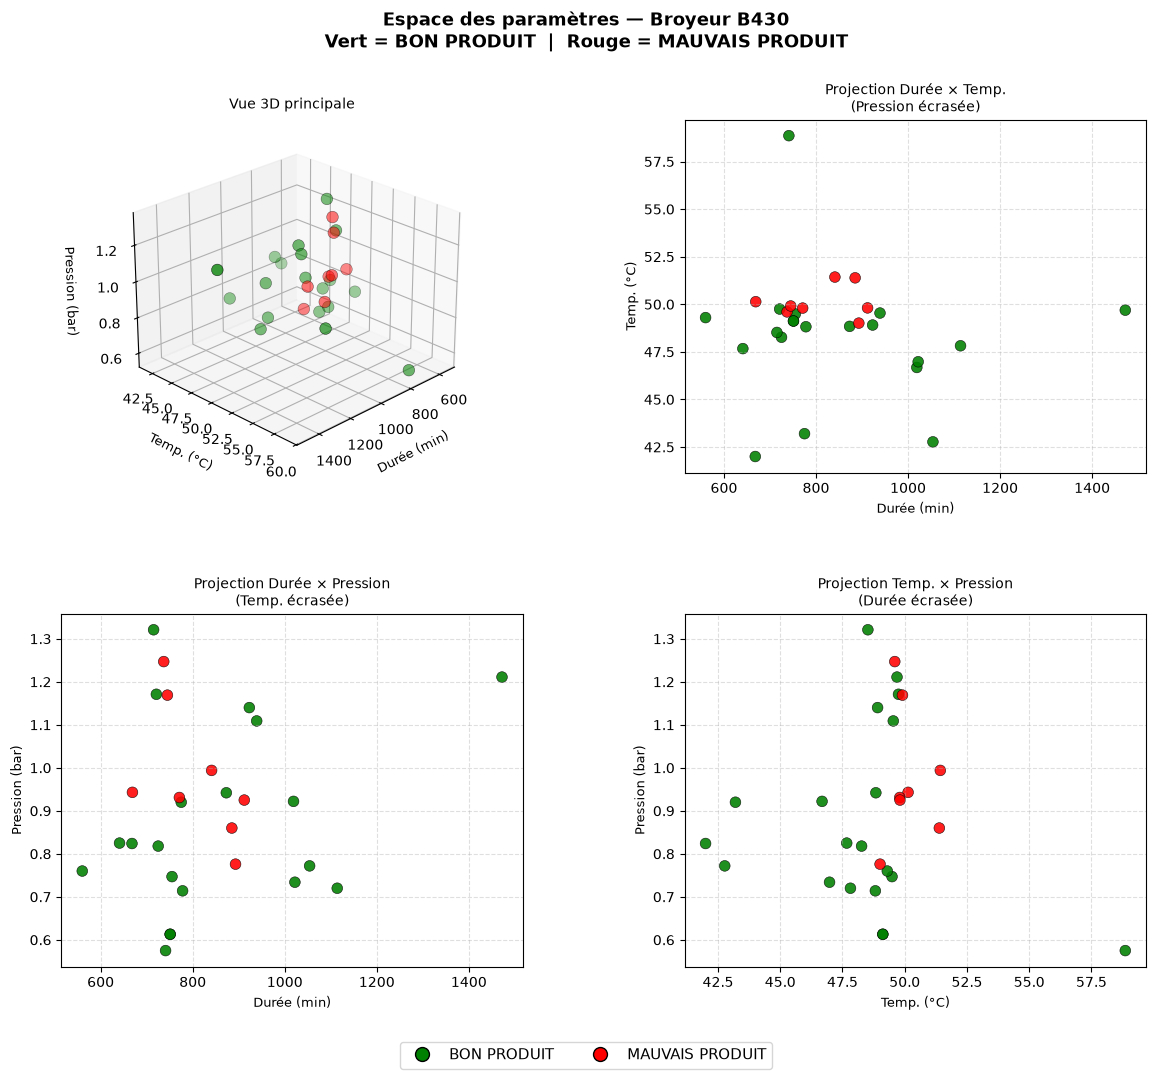

Figure sauvegardée : visualisation_3D_projections.png


In [62]:
FEATURE_COLS = ['Durée (min)', 'Temp. (°C)', 'Pression (bar)']
X_raw = df[FEATURE_COLS].values
y     = df['label'].values
colors = np.where(y == 1, 'green', 'red')

fig = plt.figure(figsize=(14, 11))
fig.suptitle('Espace des paramètres — Broyeur B430\nVert = BON PRODUIT  |  Rouge = MAUVAIS PRODUIT',
             fontsize=13, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# ── Panel 1 : scatter 3D principal ───────────────────────────────────────────
ax3d = fig.add_subplot(gs[0, 0], projection='3d')
ax3d.scatter(df['Durée (min)'], df['Temp. (°C)'], df['Pression (bar)'],
             c=colors, s=70, edgecolors='k', linewidths=0.4, alpha=0.88)
ax3d.set_xlabel('Durée (min)', fontsize=9, labelpad=6)
ax3d.set_ylabel('Temp. (°C)',  fontsize=9, labelpad=6)
ax3d.set_zlabel('Pression (bar)', fontsize=9, labelpad=6)
ax3d.set_title('Vue 3D principale', fontsize=10, pad=8)
ax3d.view_init(elev=25, azim=45)

# ── Panel 2 : projection Durée × Temp (vue de côté Pression écrasée) ─────────
ax_dt = fig.add_subplot(gs[0, 1])
ax_dt.scatter(df['Durée (min)'], df['Temp. (°C)'], c=colors,
              s=60, edgecolors='k', linewidths=0.4, alpha=0.88)
ax_dt.set_xlabel('Durée (min)', fontsize=9)
ax_dt.set_ylabel('Temp. (°C)',  fontsize=9)
ax_dt.set_title('Projection Durée × Temp.\n(Pression écrasée)', fontsize=10)
ax_dt.grid(True, linestyle='--', alpha=0.4)

# ── Panel 3 : projection Durée × Pression (vue de face Temp écrasée) ─────────
ax_dp = fig.add_subplot(gs[1, 0])
ax_dp.scatter(df['Durée (min)'], df['Pression (bar)'], c=colors,
              s=60, edgecolors='k', linewidths=0.4, alpha=0.88)
ax_dp.set_xlabel('Durée (min)',     fontsize=9)
ax_dp.set_ylabel('Pression (bar)',  fontsize=9)
ax_dp.set_title('Projection Durée × Pression\n(Temp. écrasée)', fontsize=10)
ax_dp.grid(True, linestyle='--', alpha=0.4)

# ── Panel 4 : projection Temp × Pression (vue du dessus Durée écrasée) ───────
ax_tp = fig.add_subplot(gs[1, 1])
ax_tp.scatter(df['Temp. (°C)'], df['Pression (bar)'], c=colors,
              s=60, edgecolors='k', linewidths=0.4, alpha=0.88)
ax_tp.set_xlabel('Temp. (°C)',     fontsize=9)
ax_tp.set_ylabel('Pression (bar)', fontsize=9)
ax_tp.set_title('Projection Temp. × Pression\n(Durée écrasée)', fontsize=10)
ax_tp.grid(True, linestyle='--', alpha=0.4)

# ── Légende commune ───────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='green',
           markeredgecolor='k', markersize=10, label='BON PRODUIT'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='k', markersize=10, label='MAUVAIS PRODUIT'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.01))

plt.savefig('visualisation_3D_projections.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : visualisation_3D_projections.png')

## 3. Vue sous 4 angles 3D

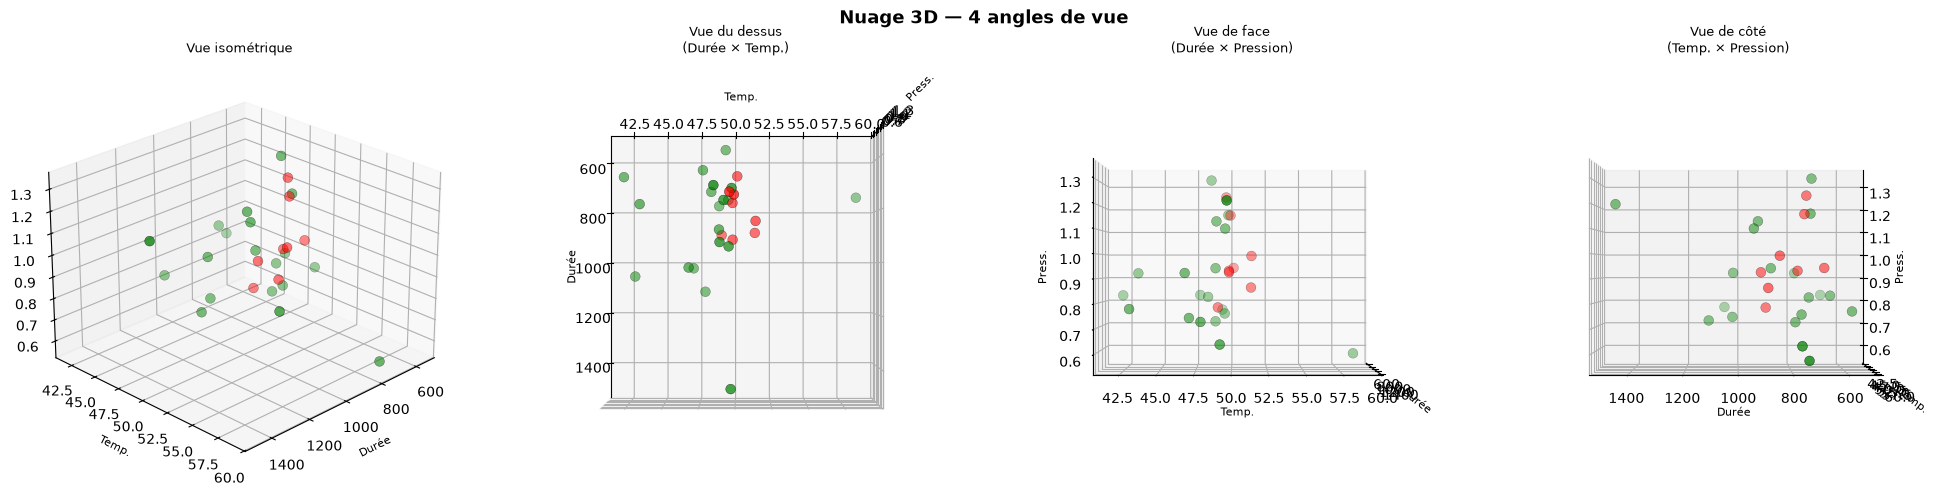

Figure sauvegardée : vues_multiples_3D.png


In [63]:
angles = [
    (25, 45,  'Vue isométrique'),
    (90,  0,  'Vue du dessus\n(Durée × Temp.)'),
    ( 0,  0,  'Vue de face\n(Durée × Pression)'),
    ( 0, 90,  'Vue de côté\n(Temp. × Pression)'),
]

fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': '3d'})
fig2.suptitle('Nuage 3D — 4 angles de vue', fontsize=13, fontweight='bold')

for ax, (elev, azim, title) in zip(axes2, angles):
    ax.scatter(df['Durée (min)'], df['Temp. (°C)'], df['Pression (bar)'],
               c=colors, s=50, edgecolors='k', linewidths=0.3, alpha=0.88)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('Durée', fontsize=8, labelpad=4)
    ax.set_ylabel('Temp.',  fontsize=8, labelpad=4)
    ax.set_zlabel('Press.', fontsize=8, labelpad=4)
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.savefig('vues_multiples_3D.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : vues_multiples_3D.png')

## 3b. Visualisation 3D interactive (Plotly)
Rotation libre à la souris, zoom, hover sur chaque lot.

In [64]:
import plotly.graph_objects as go

fig_3d = go.Figure()

for label_val, label_name, color in [(1, 'BON PRODUIT', '#2ecc71'), (0, 'MAUVAIS PRODUIT', '#e74c3c')]:
    mask = y == label_val
    fig_3d.add_trace(go.Scatter3d(
        x=X_raw[mask, 0],
        y=X_raw[mask, 1],
        z=X_raw[mask, 2],
        mode='markers',
        name=label_name,
        marker=dict(size=7, color=color, opacity=0.88, line=dict(color='black', width=0.5)),
        text=df.loc[mask, 'Lot'].astype(str),
        hovertemplate=(
            '<b>Lot %{text}</b><br>'
            'Durée : %{x:.0f} min<br>'
            'Temp. : %{y:.2f} °C<br>'
            'Pression : %{z:.3f} bar<br>'
            '<extra>%{fullData.name}</extra>'
        ),
    ))

fig_3d.update_layout(
    title=dict(text='Espace paramètres 3D — Broyeur B430', font=dict(size=15)),
    scene=dict(
        xaxis_title='Durée (min)',
        yaxis_title='Temp. (°C)',
        zaxis_title='Pression (bar)',
        xaxis=dict(backgroundcolor='#f0f0f0'),
        yaxis=dict(backgroundcolor='#e8e8e8'),
        zaxis=dict(backgroundcolor='#f8f8f8'),
    ),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)', bordercolor='grey', borderwidth=1),
    width=850,
    height=620,
    margin=dict(l=0, r=0, t=50, b=0),
)

fig_3d.show()

## 4. Standardisation des variables

In [65]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print('Moyennes après scaling (doivent être ~0) :', X.mean(axis=0).round(4))
print('Écarts-types après scaling (doivent être ~1):', X.std(axis=0).round(4))

Moyennes après scaling (doivent être ~0) : [-0. -0. -0.]
Écarts-types après scaling (doivent être ~1): [1. 1. 1.]


## 5. Définition des modèles

Variantes testées : noyaux `linear`, `rbf`, `poly` (deg 2 et 3), `NuSVC`, et Random Forest.
`class_weight='balanced'` est activé sur tous les SVM pour corriger le déséquilibre 20 BON / 8 MAUVAIS.

In [66]:
models = {
    'SVM Linéaire':           SVC(kernel='linear', C=1, random_state=42),
    'SVM Linéaire (bal.)':    SVC(kernel='linear', C=0.001, class_weight='balanced', random_state=42),
    'SVM RBF':                SVC(kernel='rbf',    C=10,   gamma=0.1,  random_state=42),
    'SVM RBF (bal.)':         SVC(kernel='rbf',    C=1,    gamma=1.0,  class_weight='balanced', random_state=42),
    'SVM Poly deg=2 (bal.)':  SVC(kernel='poly',   degree=2, C=0.001,  class_weight='balanced', random_state=42),
    'SVM Poly deg=3 (bal.)':  SVC(kernel='poly',   degree=3, C=0.001,  class_weight='balanced', random_state=42),
    'NuSVC RBF (bal.)':       NuSVC(kernel='rbf',  nu=0.2,   class_weight='balanced'),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
}

## 6. Évaluation — Leave-One-Out Cross-Validation

In [67]:
loo = LeaveOneOut()
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=loo, scoring='accuracy', n_jobs=-1)
    results[name] = {
        'Accuracy LOOCV': scores.mean(),
        'Écart-type':     scores.std(),
        'N fabrications': len(scores),
    }
    print(f'{name:20s}: {scores.mean():.1%} ± {scores.std():.1%}')

SVM Linéaire        : 60.7% ± 48.8%
SVM Linéaire (bal.) : 71.4% ± 45.2%
SVM RBF             : 82.1% ± 38.3%
SVM RBF (bal.)      : 82.1% ± 38.3%
SVM Poly deg=2 (bal.): 71.4% ± 45.2%
SVM Poly deg=3 (bal.): 71.4% ± 45.2%
NuSVC RBF (bal.)    : 78.6% ± 41.0%
Random Forest       : 85.7% ± 35.0%


## 7. Tableau comparatif des modèles

In [68]:
df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = ['Modèle', 'Accuracy LOOCV', 'Écart-type', 'N fabrications']
df_results['Accuracy LOOCV'] = df_results['Accuracy LOOCV'].astype(float)
df_results = df_results.sort_values('Accuracy LOOCV', ascending=False).reset_index(drop=True)

best_idx = df_results['Accuracy LOOCV'].idxmax()
df_results[''] = ''
df_results.loc[best_idx, ''] = '★ Meilleur'

best_name = df_results.loc[best_idx, 'Modèle']
best_acc  = df_results.loc[best_idx, 'Accuracy LOOCV']
print(f'Meilleur modèle : {best_name} — Accuracy LOOCV = {best_acc:.1%}\n')

df_results.style \
    .highlight_max(subset=['Accuracy LOOCV'], color='#c8f7c5') \
    .format({'Accuracy LOOCV': '{:.1%}', 'Écart-type': '{:.1%}', 'N fabrications': '{:.0f}'})

Meilleur modèle : Random Forest — Accuracy LOOCV = 85.7%



,Modèle,Accuracy LOOCV,Écart-type,N fabrications,
0,Random Forest,85.7%,35.0%,28,★ Meilleur
1,SVM RBF (bal.),82.1%,38.3%,28,
2,SVM RBF,82.1%,38.3%,28,
3,NuSVC RBF (bal.),78.6%,41.0%,28,
4,SVM Poly deg=3 (bal.),71.4%,45.2%,28,
5,SVM Linéaire (bal.),71.4%,45.2%,28,
6,SVM Poly deg=2 (bal.),71.4%,45.2%,28,
7,SVM Linéaire,60.7%,48.8%,28,


## 8. Optimisation — GridSearchCV sur SVM RBF (bal.)

Recherche des meilleurs paramètres `C` et `gamma` avec LOOCV.

In [69]:
if RUN_OPTIMIZATION:
    param_grid = {
        'C':     [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1.0],
    }
    grid = GridSearchCV(
        SVC(kernel='rbf', class_weight='balanced'),
        param_grid,
        cv=LeaveOneOut(),
        scoring='accuracy',
        n_jobs=-1,
    )
    grid.fit(X, y)

    print(f"Meilleurs paramètres : {grid.best_params_}")
    print(f"Meilleure accuracy LOOCV : {grid.best_score_:.1%}")

    cv_res = pd.DataFrame(grid.cv_results_)[['param_C', 'param_gamma', 'mean_test_score', 'rank_test_score']]
    cv_res.columns = ['C', 'gamma', 'Accuracy LOOCV', 'Rang']
    cv_res = cv_res.sort_values('Rang').head(10).reset_index(drop=True)
    display(cv_res.style
        .highlight_min(subset=['Rang'], color='#c8f7c5')
        .format({'Accuracy LOOCV': '{:.1%}'}))

## 8b. Optimisation complète — C pour tous les SVM, nu pour NuSVC

GridSearchCV avec LOOCV sur chaque variante SVM pour trouver le meilleur C (et nu). Comparaison finale avec Random Forest.

In [70]:
if RUN_OPTIMIZATION:
    import warnings
    warnings.filterwarnings('ignore')

    C_range  = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    nu_range = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

    svm_grids = {
        'SVM Linéaire':          (SVC(kernel='linear', random_state=42),
                                   {'C': C_range}),
        'SVM Linéaire (bal.)':   (SVC(kernel='linear', class_weight='balanced', random_state=42),
                                   {'C': C_range}),
        'SVM RBF':               (SVC(kernel='rbf', random_state=42),
                                   {'C': C_range, 'gamma': [0.001, 0.01, 0.1, 1.0, 10, 'scale']}),
        'SVM RBF (bal.)':        (SVC(kernel='rbf', class_weight='balanced', random_state=42),
                                   {'C': C_range, 'gamma': [0.001, 0.01, 0.1, 1.0, 10, 'scale']}),
        'SVM Poly deg=2 (bal.)':(SVC(kernel='poly', degree=2, class_weight='balanced', random_state=42),
                                   {'C': C_range}),
        'SVM Poly deg=3 (bal.)':(SVC(kernel='poly', degree=3, class_weight='balanced', random_state=42),
                                   {'C': C_range}),
        'NuSVC RBF (bal.)':      (NuSVC(kernel='rbf', class_weight='balanced'),
                                   {'nu': nu_range}),
    }

    opt_results = {}
    for name, (model, params) in svm_grids.items():
        gs = GridSearchCV(model, params, cv=LeaveOneOut(), scoring='accuracy',
                          n_jobs=-1, error_score=0.0)
        gs.fit(X, y)
        opt_results[name] = {'Accuracy LOOCV': gs.best_score_, 'Meilleurs params': gs.best_params_}
        print(f'{name:25s}: {gs.best_score_:.1%}  →  {gs.best_params_}')

    rf_acc = results['Random Forest']['Accuracy LOOCV']
    print(f"\n{'Random Forest':25s}: {rf_acc:.1%}  →  n_estimators=100")

    rows = [{'Modèle': k, 'Accuracy LOOCV': v['Accuracy LOOCV'], 'Meilleurs paramètres': str(v['Meilleurs params'])}
            for k, v in opt_results.items()]
    rows.append({'Modèle': 'Random Forest', 'Accuracy LOOCV': rf_acc, 'Meilleurs paramètres': 'n_estimators=100'})

    df_opt = pd.DataFrame(rows).sort_values('Accuracy LOOCV', ascending=False).reset_index(drop=True)
    display(df_opt.style
        .highlight_max(subset=['Accuracy LOOCV'], color='#c8f7c5')
        .highlight_min(subset=['Accuracy LOOCV'], color='#ffd6d6')
        .format({'Accuracy LOOCV': '{:.1%}'}))

## 8c. Zones de décision 3D — SVM RBF, Linéaire, Poly + Random Forest

- **SVM RBF** : bulle orange = zone MAUVAIS à éviter — BON PRODUIT = tout l'extérieur de la bulle
- **SVM Linéaire / Poly** : surface bleue = frontière BON ↔ MAUVAIS
- **Random Forest** : 3 surfaces vertes imbriquées à P(BON) = 50%, 70%, 90% — plus foncé = plus sûr

In [71]:
import warnings
warnings.filterwarnings('ignore')

viz_models = {
    'SVM RBF (bal.)':         SVC(kernel='rbf',    C=1,   gamma=1.0, class_weight='balanced', random_state=42),
    'SVM Linéaire (bal.)':    SVC(kernel='linear', C=100, class_weight='balanced', random_state=42),
    'SVM Poly deg=3 (bal.)':  SVC(kernel='poly',   degree=3, C=100, class_weight='balanced', random_state=42),
}
for model in viz_models.values():
    model.fit(X, y)

n_grid = 25
margin = 1.5
axes_scaled = [np.linspace(X[:, i].min() - margin, X[:, i].max() + margin, n_grid) for i in range(3)]
xx0, xx1, xx2 = np.meshgrid(*axes_scaled)
grid_scaled = np.c_[xx0.ravel(), xx1.ravel(), xx2.ravel()]
grid_orig   = scaler.inverse_transform(grid_scaled)

scatter_traces = []
for label_val, label_name, color in [(1, 'BON', '#2ecc71'), (0, 'MAUVAIS', '#e74c3c')]:
    mask = y == label_val
    scatter_traces.append(go.Scatter3d(
        x=X_raw[mask, 0], y=X_raw[mask, 1], z=X_raw[mask, 2],
        mode='markers', name=label_name,
        marker=dict(size=7, color=color, opacity=0.95, line=dict(color='black', width=0.5)),
        text=df.loc[mask, 'Lot'].astype(str),
        hovertemplate='<b>Lot %{text}</b><br>Durée: %{x:.0f} min<br>Temp: %{y:.2f} °C<br>Pression: %{z:.3f} bar<extra>%{fullData.name}</extra>',
    ))

scene_layout = dict(
    xaxis_title='Durée (min)', yaxis_title='Temp. (°C)', zaxis_title='Pression (bar)',
    xaxis=dict(backgroundcolor='#f0f0f0'),
    yaxis=dict(backgroundcolor='#e8e8e8'),
    zaxis=dict(backgroundcolor='#f8f8f8'),
)

# ── SVM RBF : bulle orange = zone MAUVAIS à éviter ───────────────────────────
Z_rbf = viz_models['SVM RBF (bal.)'].decision_function(grid_scaled).reshape(xx0.shape)
fig_rbf = go.Figure()
if Z_rbf.min() * Z_rbf.max() < 0:
    fig_rbf.add_trace(go.Isosurface(
        x=grid_orig[:, 0].flatten(), y=grid_orig[:, 1].flatten(), z=grid_orig[:, 2].flatten(),
        value=Z_rbf.flatten(),
        isomin=0, isomax=0, surface_count=1,
        colorscale=[[0, '#e67e22'], [1, '#e67e22']],
        showscale=False, opacity=0.35, name='Zone MAUVAIS',
        caps=dict(x_show=False, y_show=False, z_show=False),
    ))
for t in scatter_traces:
    fig_rbf.add_trace(t)
fig_rbf.update_layout(
    title=dict(text='SVM RBF (bal.) — Bulle orange = zone MAUVAIS à éviter<br><sup>BON PRODUIT = paramètres hors de la bulle</sup>', font=dict(size=13)),
    scene=scene_layout, legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
    width=850, height=620, margin=dict(l=0, r=0, t=70, b=0),
)
fig_rbf.show()

# ── SVM Linéaire et Poly : frontières bleues ──────────────────────────────────
for name in ['SVM Linéaire (bal.)', 'SVM Poly deg=3 (bal.)']:
    Z = viz_models[name].decision_function(grid_scaled).reshape(xx0.shape)
    fig_b = go.Figure()
    if Z.min() * Z.max() < 0:
        fig_b.add_trace(go.Isosurface(
            x=grid_orig[:, 0].flatten(), y=grid_orig[:, 1].flatten(), z=grid_orig[:, 2].flatten(),
            value=Z.flatten(),
            isomin=0, isomax=0, surface_count=1,
            colorscale=[[0, '#3498db'], [1, '#3498db']],
            showscale=False, opacity=0.4, name='Frontière',
            caps=dict(x_show=False, y_show=False, z_show=False),
        ))
        note = 'Frontière visible'
    else:
        side = 'BON partout' if Z.min() > 0 else 'MAUVAIS partout'
        note = f'Pas de frontière ({side})'
        print(f'⚠  {name} : {note}')
    for t in scatter_traces:
        fig_b.add_trace(t)
    fig_b.update_layout(
        title=dict(text=f'Frontière de décision — {name}<br><sup>{note}</sup>', font=dict(size=13)),
        scene=scene_layout, legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
        width=850, height=620, margin=dict(l=0, r=0, t=70, b=0),
    )
    fig_b.show()

# ── Random Forest : 3 seuils de confiance 50 / 70 / 90 % ─────────────────────
Z_rf_proba = rf_final.predict_proba(grid_scaled)[:, 1].reshape(xx0.shape)
fig_rf = go.Figure()
fig_rf.add_trace(go.Isosurface(
    x=grid_orig[:, 0].flatten(), y=grid_orig[:, 1].flatten(), z=grid_orig[:, 2].flatten(),
    value=Z_rf_proba.flatten(),
    isomin=0.5, isomax=0.9, surface_count=3,
    colorscale=[[0, '#a9dfbf'], [0.5, '#27ae60'], [1, '#1a5632']],
    showscale=True, opacity=0.25, name='Zone BON',
    caps=dict(x_show=False, y_show=False, z_show=False),
    colorbar=dict(title='P(BON)', tickvals=[0.5, 0.7, 0.9], ticktext=['50%', '70%', '90%'], x=0.9),
))
for t in scatter_traces:
    fig_rf.add_trace(t)
fig_rf.update_layout(
    title=dict(text='Random Forest — Zone BON à 3 niveaux de confiance<br><sup>Surfaces à P(BON) = 50%, 70%, 90% — plus foncé = plus sûr</sup>', font=dict(size=13)),
    scene=scene_layout, legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
    width=850, height=620, margin=dict(l=0, r=0, t=70, b=0),
)
fig_rf.show()

## 8. Importance des variables — Random Forest

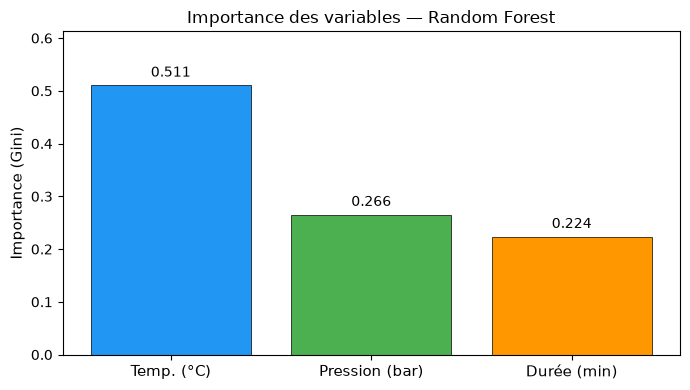

Figure sauvegardée : feature_importance_RF.png


In [72]:
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X, y)

importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = [FEATURE_COLS[i] for i in indices]

fig3, ax3 = plt.subplots(figsize=(7, 4))
bars = ax3.bar(range(len(FEATURE_COLS)), importances[indices],
               color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='k', linewidth=0.5)
ax3.set_xticks(range(len(FEATURE_COLS)))
ax3.set_xticklabels(feat_names, fontsize=11)
ax3.set_ylabel('Importance (Gini)', fontsize=11)
ax3.set_title('Importance des variables — Random Forest', fontsize=12)
ax3.set_ylim(0, max(importances) * 1.2)

for bar, imp in zip(bars, importances[indices]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{imp:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance_RF.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : feature_importance_RF.png')

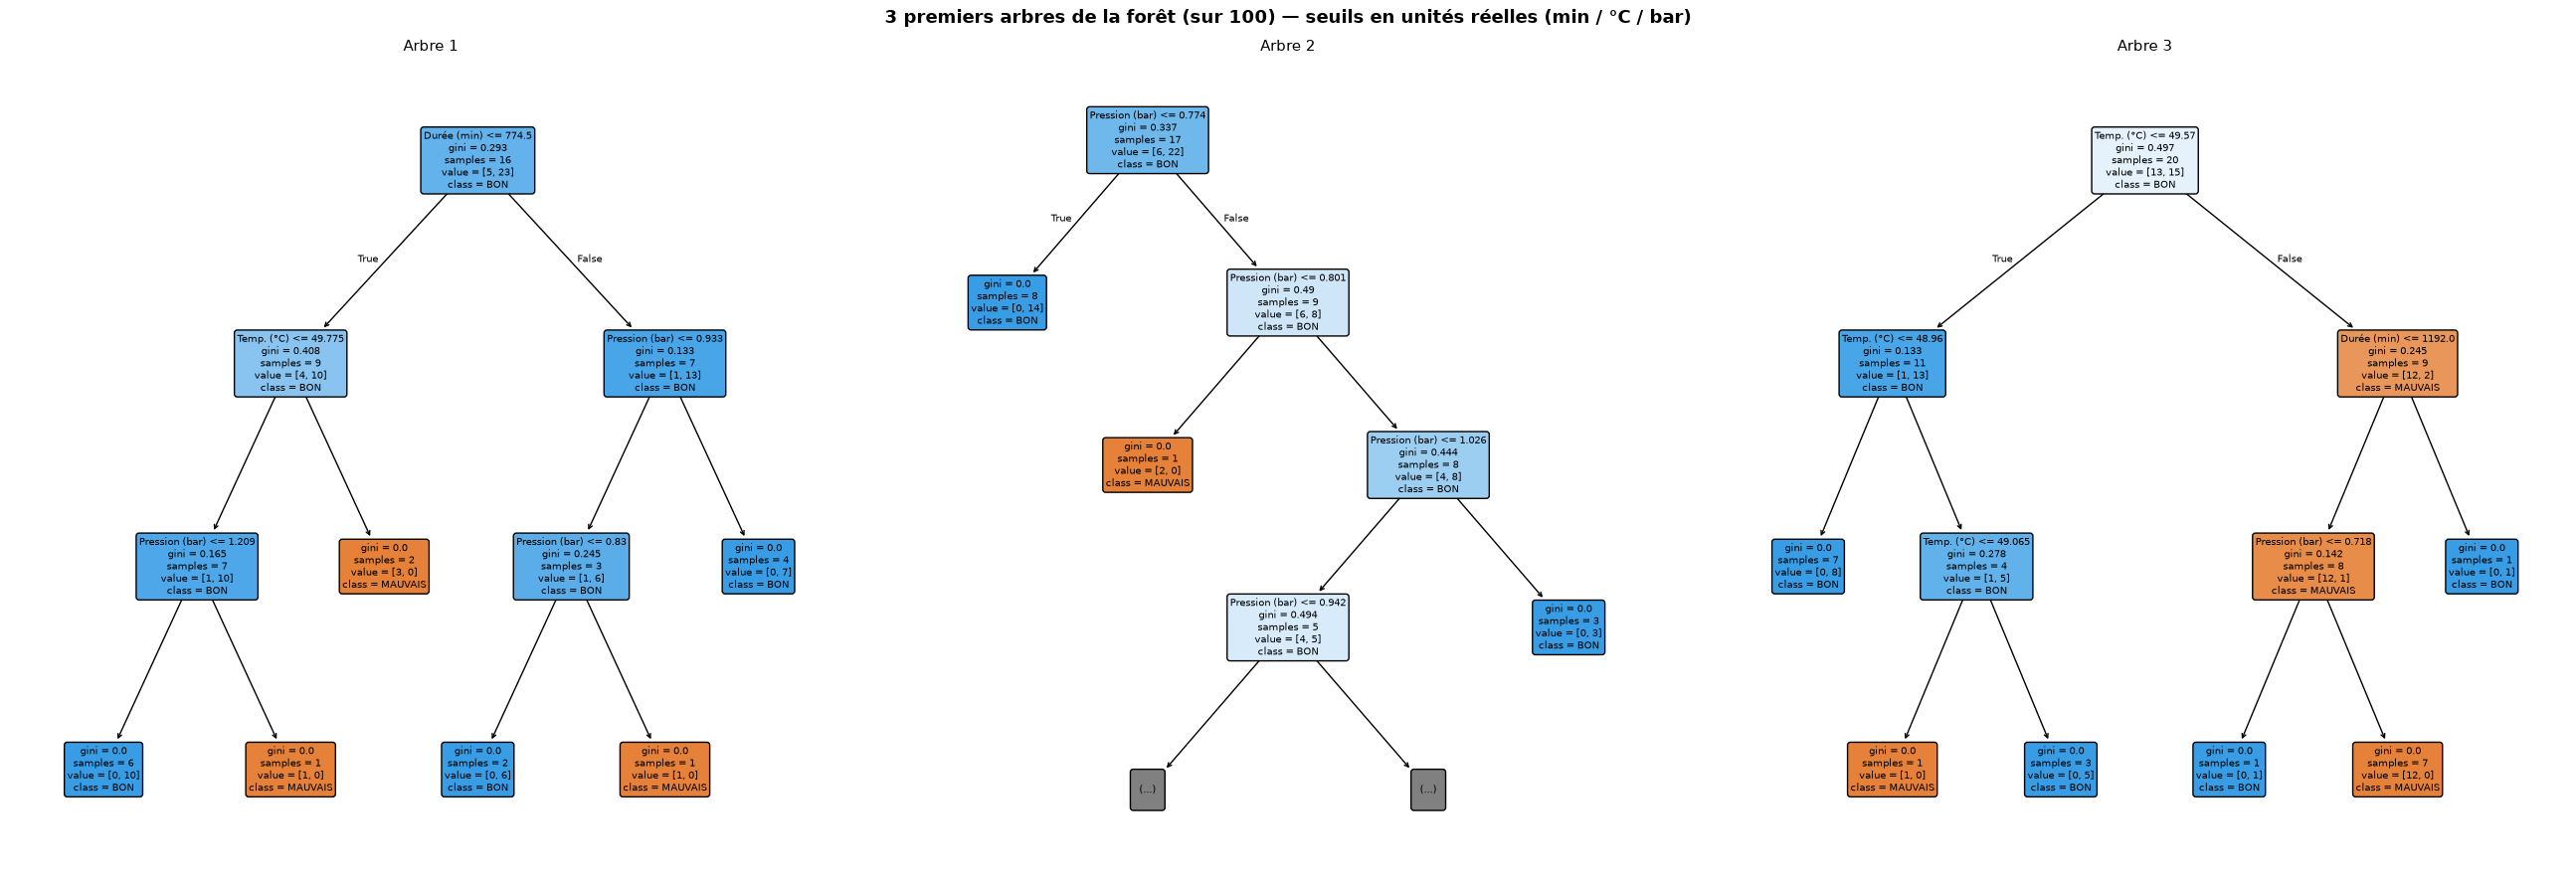

Figure sauvegardée : arbres_foret.png


In [73]:
from sklearn.tree import plot_tree

# RF entraîné sur données brutes (pas normalisées) → seuils lisibles en min / °C / bar
rf_viz = RandomForestClassifier(n_estimators=100, random_state=42)
rf_viz.fit(X_raw, y)

fig, axes = plt.subplots(1, 3, figsize=(26, 9))
fig.suptitle('3 premiers arbres de la forêt (sur 100) — seuils en unités réelles (min / °C / bar)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes):
    plot_tree(
        rf_viz.estimators_[i],
        feature_names=FEATURE_COLS,
        class_names=['MAUVAIS', 'BON'],
        filled=True,
        rounded=True,
        fontsize=7,
        ax=ax,
        max_depth=3,
    )
    ax.set_title(f'Arbre {i + 1}', fontsize=11)

plt.tight_layout()
plt.savefig('arbres_foret.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : arbres_foret.png')

## 10. Optimisation — Nombre d'arbres (Random Forest)

Test de n_estimators de 5 à 1000 avec LOOCV pour trouver le seuil de stabilité.

In [74]:
if RUN_OPTIMIZATION:
    import warnings
    warnings.filterwarnings('ignore')

    n_trees_range = [5, 10, 20, 50, 100, 200, 500, 1000]
    tree_results = {}

    for n in n_trees_range:
        rf = RandomForestClassifier(n_estimators=n, random_state=42)
        scores = cross_val_score(rf, X, y, cv=LeaveOneOut(), scoring='accuracy', n_jobs=-1)
        tree_results[n] = scores.mean()
        print(f'n_estimators={n:5d} : {scores.mean():.1%}')

    best_n   = max(tree_results, key=tree_results.get)
    best_acc = tree_results[best_n]
    print(f'\nMeilleur : n_estimators={best_n} → {best_acc:.1%}')

    fig4, ax4 = plt.subplots(figsize=(8, 4))
    ns   = list(tree_results.keys())
    accs = [v * 100 for v in tree_results.values()]

    ax4.plot(ns, accs, marker='o', color='#2196F3', linewidth=2, markersize=7)
    ax4.axhline(y=best_acc * 100, color='green', linestyle='--', alpha=0.5, label=f'Max = {best_acc:.1%}')
    ax4.set_xscale('log')
    ax4.set_xlabel("Nombre d'arbres (n_estimators)", fontsize=11)
    ax4.set_ylabel("Accuracy LOOCV (%)", fontsize=11)
    ax4.set_title("Impact du nombre d'arbres — Random Forest", fontsize=12)
    ax4.set_xticks(ns)
    ax4.set_xticklabels(ns)
    ax4.legend(fontsize=10)
    ax4.grid(True, linestyle='--', alpha=0.4)

    for n, acc in zip(ns, accs):
        ax4.annotate(f'{acc:.1%}', (n, acc), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('optimisation_n_arbres.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure sauvegardée : optimisation_n_arbres.png')

## 11. Conclusions

- Le **meilleur modèle LOOCV** est celui qui généralise le mieux sur vos fabrications réelles.
- Le graphique d'**importance des variables** (Random Forest) indique quel paramètre (Durée, Température ou Pression) influence le plus la qualité du produit.
- Avec un petit jeu de données (< 30 points), l'accuracy LOOCV peut varier sensiblement selon les lots — **collecter davantage de données** renforcerait la fiabilité du modèle.
- Les **zones vertes** visibles dans les projections 2D représentent les plages de paramètres associées aux bons produits : c'est la cible opérationnelle à maintenir.

## 12. Zones de validité opérationnelles — SVM RBF & Random Forest

Carte de chaleur de P(BON) pour chaque paire de paramètres (moyenne sur le 3ème).
- **Ligne noire** = seuil 50%
- **Ligne bleue** = seuil 70%
- **Ligne or** = seuil 90%

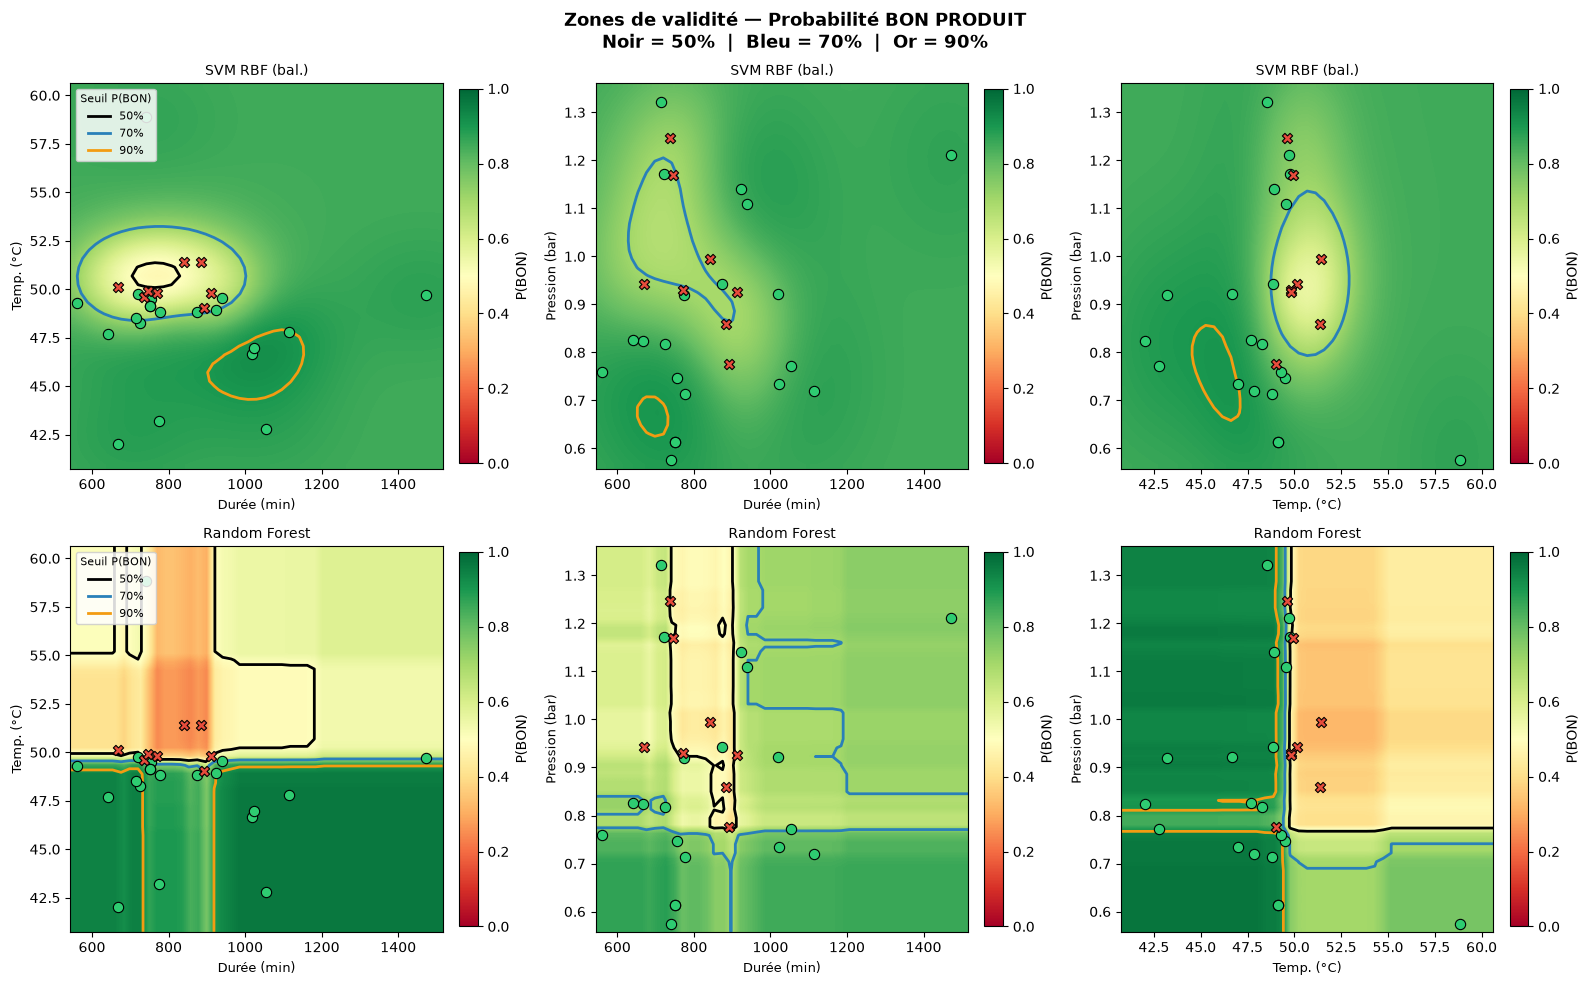

Figure sauvegardée : zones_validite.png

PLAGES DE PARAMÈTRES → BON PRODUIT (prédiction > 50%)

  SVM RBF (bal.)
    Durée (min)         : 532.0  →  1545.6
    Temp. (°C)          : 39.9  →  61.8
    Pression (bar)      : 0.5  →  1.4

  Random Forest
    Durée (min)         : 532.0  →  1545.6
    Temp. (°C)          : 39.9  →  61.8
    Pression (bar)      : 0.5  →  1.4


In [75]:
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')

svm_zone = SVC(kernel='rbf', C=1, gamma=1.0, class_weight='balanced', probability=True, random_state=42)
svm_zone.fit(X, y)

zone_models = {'SVM RBF (bal.)': svm_zone, 'Random Forest': rf_final}

pairs = [
    (0, 1, 2, 'Durée (min)', 'Temp. (°C)'),
    (0, 2, 1, 'Durée (min)', 'Pression (bar)'),
    (1, 2, 0, 'Temp. (°C)', 'Pression (bar)'),
]

n_hm  = 45
n_avg = 12

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Zones de validité — Probabilité BON PRODUIT\n'
             'Noir = 50%  |  Bleu = 70%  |  Or = 90%',
             fontsize=13, fontweight='bold')

legend_lines = [
    Line2D([0], [0], color='black',   linewidth=2, label='50%'),
    Line2D([0], [0], color='#2980b9', linewidth=2, label='70%'),
    Line2D([0], [0], color='#f39c12', linewidth=2, label='90%'),
]

for row, (mname, mmodel) in enumerate(zone_models.items()):
    for col, (i, j, k, xlabel, ylabel) in enumerate(pairs):
        ax = axes[row, col]

        xi_vals = np.linspace(X_raw[:, i].min() * 0.97, X_raw[:, i].max() * 1.03, n_hm)
        xj_vals = np.linspace(X_raw[:, j].min() * 0.97, X_raw[:, j].max() * 1.03, n_hm)
        xk_vals = np.linspace(X_raw[:, k].min(), X_raw[:, k].max(), n_avg)

        xi_g, xj_g = np.meshgrid(xi_vals, xj_vals)
        xi_flat, xj_flat = xi_g.ravel(), xj_g.ravel()

        pts = np.zeros((len(xi_flat) * n_avg, 3))
        pts[:, i] = np.repeat(xi_flat, n_avg)
        pts[:, j] = np.repeat(xj_flat, n_avg)
        pts[:, k] = np.tile(xk_vals, len(xi_flat))
        pts_scaled = scaler.transform(pts)

        proba   = mmodel.predict_proba(pts_scaled)[:, 1]
        heatmap = proba.reshape(len(xi_flat), n_avg).mean(axis=1).reshape(n_hm, n_hm)

        im = ax.imshow(heatmap, origin='lower', aspect='auto',
                       extent=[xi_vals[0], xi_vals[-1], xj_vals[0], xj_vals[-1]],
                       cmap='RdYlGn', vmin=0, vmax=1, interpolation='bilinear')

        ax.contour(xi_vals, xj_vals, heatmap, levels=[0.5], colors='black',   linewidths=2)
        ax.contour(xi_vals, xj_vals, heatmap, levels=[0.7], colors='#2980b9', linewidths=2)
        ax.contour(xi_vals, xj_vals, heatmap, levels=[0.9], colors='#f39c12', linewidths=2)

        for lv, clr, mk in [(1, '#2ecc71', 'o'), (0, '#e74c3c', 'X')]:
            mask = y == lv
            ax.scatter(X_raw[mask, i], X_raw[mask, j],
                       c=clr, s=55, marker=mk, edgecolors='k', linewidths=0.8, zorder=5)

        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(mname, fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='P(BON)')

        if col == 0:
            ax.legend(handles=legend_lines, title='Seuil P(BON)',
                      fontsize=8, title_fontsize=8, loc='upper left', framealpha=0.85)

plt.tight_layout()
plt.savefig('zones_validite.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : zones_validite.png')

# ── Tableau des plages de validité ───────────────────────────────────────────
n_fine = 40
axes_fine = [np.linspace(X_raw[:, i].min() * 0.95, X_raw[:, i].max() * 1.05, n_fine) for i in range(3)]
gf0, gf1, gf2 = np.meshgrid(*axes_fine)
grid_fine   = np.c_[gf0.ravel(), gf1.ravel(), gf2.ravel()]
grid_fine_s = scaler.transform(grid_fine)

print('\n' + '='*60)
print('PLAGES DE PARAMÈTRES → BON PRODUIT (prédiction > 50%)')
print('='*60)
for mname, mmodel in zone_models.items():
    bon_pts = grid_fine[mmodel.predict_proba(grid_fine_s)[:, 1] > 0.5]
    print(f'\n  {mname}')
    for idx, col in enumerate(FEATURE_COLS):
        print(f'    {col:20s}: {bon_pts[:, idx].min():.1f}  →  {bon_pts[:, idx].max():.1f}')

## 12b. Zones de validité 3D interactives — SVM RBF & Random Forest

Même information que la section 12 mais en 3D interactif (rotation, zoom, hover).
Surfaces emboîtées à P(BON) = 50% (vert clair), 70% (vert moyen), 90% (vert foncé).
Points réels superposés — restez dans le cœur foncé pour maximiser la confiance.

In [76]:
import warnings
warnings.filterwarnings('ignore')

# svm_zone et rf_final déjà entraînés (sections 12 et 9)
# grid_scaled et grid_orig déjà calculés (section 8c)

validity_models = {
    'SVM RBF (bal.) — probabilités': svm_zone,
    'Random Forest':                  rf_final,
}

scene_layout = dict(
    xaxis_title='Durée (min)', yaxis_title='Temp. (°C)', zaxis_title='Pression (bar)',
    xaxis=dict(backgroundcolor='#f0f0f0'),
    yaxis=dict(backgroundcolor='#e8e8e8'),
    zaxis=dict(backgroundcolor='#f8f8f8'),
)

for mname, mmodel in validity_models.items():
    Z_proba = mmodel.predict_proba(grid_scaled)[:, 1].reshape(xx0.shape)

    fig_v = go.Figure()

    fig_v.add_trace(go.Isosurface(
        x=grid_orig[:, 0].flatten(),
        y=grid_orig[:, 1].flatten(),
        z=grid_orig[:, 2].flatten(),
        value=Z_proba.flatten(),
        isomin=0.5, isomax=0.9,
        surface_count=3,
        colorscale=[[0, '#a9dfbf'], [0.5, '#27ae60'], [1, '#1a5632']],
        showscale=True,
        opacity=0.25,
        name='Zone BON',
        caps=dict(x_show=False, y_show=False, z_show=False),
        colorbar=dict(
            title='P(BON)',
            tickvals=[0.5, 0.7, 0.9],
            ticktext=['50%', '70%', '90%'],
            x=0.9,
        ),
    ))

    for label_val, label_name, color in [(1, 'BON', '#2ecc71'), (0, 'MAUVAIS', '#e74c3c')]:
        mask = y == label_val
        fig_v.add_trace(go.Scatter3d(
            x=X_raw[mask, 0], y=X_raw[mask, 1], z=X_raw[mask, 2],
            mode='markers', name=label_name,
            marker=dict(size=7, color=color, opacity=0.95, line=dict(color='black', width=0.5)),
            text=df.loc[mask, 'Lot'].astype(str),
            hovertemplate='<b>Lot %{text}</b><br>Durée: %{x:.0f} min<br>Temp: %{y:.2f} °C<br>Pression: %{z:.3f} bar<extra>%{fullData.name}</extra>',
        ))

    fig_v.update_layout(
        title=dict(
            text=f'Zones de validité 3D — {mname}<br>'
                 '<sup>Vert clair = 50% | Vert moyen = 70% | Vert foncé = 90% de confiance BON</sup>',
            font=dict(size=13),
        ),
        scene=scene_layout,
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)', bordercolor='grey', borderwidth=1),
        width=850, height=640,
        margin=dict(l=0, r=0, t=80, b=0),
    )
    fig_v.show()

In [78]:
import warnings
warnings.filterwarnings('ignore')

# Grille fine commune
n_fine = 50
axes_fine = [np.linspace(X_raw[:, i].min() * 0.95, X_raw[:, i].max() * 1.05, n_fine) for i in range(3)]
gf0, gf1, gf2 = np.meshgrid(*axes_fine)
grid_fine   = np.c_[gf0.ravel(), gf1.ravel(), gf2.ravel()]
grid_fine_s = scaler.transform(grid_fine)

# svm_zone entraîné avec probability=True (section 12), rf_final (section 9)
models_90 = {
    'Random Forest':       rf_final,
    'SVM RBF (bal.)':      svm_zone,
}

for mname, mmodel in models_90.items():
    proba_fine = mmodel.predict_proba(grid_fine_s)[:, 1]
    zone_90    = grid_fine[proba_fine >= 0.90]

    print(f'╔══════════════════════════════════════════════════════════════╗')
    print(f'║   PLAGE DE PARAMÈTRES — BON PRODUIT à ≥ 90% de confiance    ║')
    print(f'║   {mname:^56s}  ║')
    print(f'╠══════════════════════════════════════════════════════════════╣')
    for idx, col in enumerate(FEATURE_COLS):
        lo   = zone_90[:, idx].min()
        hi   = zone_90[:, idx].max()
        unit = col.split('(')[1].rstrip(')')
        print(f'║  {col:20s}  :  {lo:7.1f}  →  {hi:7.1f}  {unit:5s}  ║')
    print(f'╚══════════════════════════════════════════════════════════════╝')
    print(f'  {len(zone_90):,} points sur {len(grid_fine):,} ({len(zone_90)/len(grid_fine):.1%}) atteignent ≥ 90%\n')

╔══════════════════════════════════════════════════════════════╗
║   PLAGE DE PARAMÈTRES — BON PRODUIT à ≥ 90% de confiance    ║
║                        Random Forest                        ║
╠══════════════════════════════════════════════════════════════╣
║  Durée (min)           :    532.0  →   1545.6  min    ║
║  Temp. (°C)            :     39.9  →     49.3  °C     ║
║  Pression (bar)        :      0.5  →      1.4  bar    ║
╚══════════════════════════════════════════════════════════════╝
  43,585 points sur 125,000 (34.9%) atteignent ≥ 90%

╔══════════════════════════════════════════════════════════════╗
║   PLAGE DE PARAMÈTRES — BON PRODUIT à ≥ 90% de confiance    ║
║                        SVM RBF (bal.)                       ║
╠══════════════════════════════════════════════════════════════╣
║  Durée (min)           :    532.0  →   1545.6  min    ║
║  Temp. (°C)            :     40.8  →     60.5  °C     ║
║  Pression (bar)        :      0.5  →      1.3  bar    ║
╚════════════════